# Performance Analytics
This notebook computes daily returns, risk-adjusted performance measures, a composite fund scorecard, alpha/beta statistics, and a benchmark comparison chart for the selected mutual fund schemes.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

base_path = Path('C:/Users/JAY MISTRY/OneDrive/Desktop/Bluestock_mf_capstone')
processed_path = base_path / 'data' / 'processed'
output_dir = base_path / 'reports'
output_dir.mkdir(exist_ok=True)

fund_master = pd.read_csv(processed_path / '01_fund_master.csv')
nav_history = pd.read_csv(processed_path / '02_nav_history.csv')
benchmark_indices = pd.read_csv(processed_path / '10_benchmark_indices.csv')

nav_history['date'] = pd.to_datetime(nav_history['date'])
nav_history = nav_history.sort_values(['amfi_code', 'date'])

# Select the first 40 schemes that have NAV history available
selected_codes = fund_master.loc[fund_master['amfi_code'].isin(nav_history['amfi_code'].unique()), 'amfi_code'].tolist()[:40]
nav_history = nav_history[nav_history['amfi_code'].isin(selected_codes)].copy()

fund_lookup = fund_master.set_index('amfi_code')['scheme_name'].to_dict()

print(f'Loaded {len(selected_codes)} funds and {len(nav_history)} NAV rows.')

Loaded 40 funds and 46000 NAV rows.


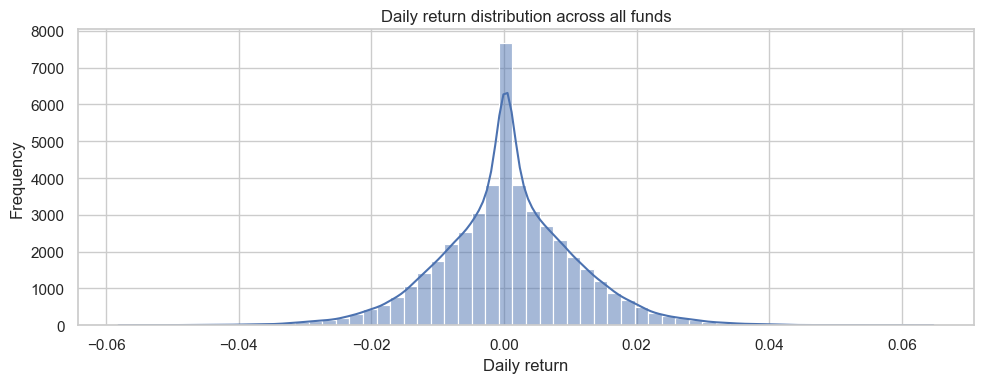

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [12]:
# 1) Daily returns: nav_t / nav_t-1 - 1

def compute_daily_returns(frame):
    frame = frame.sort_values(['amfi_code', 'date']).copy()
    frame['prev_nav'] = frame.groupby('amfi_code')['nav'].shift(1)
    frame['daily_return'] = frame['nav'] / frame['prev_nav'] - 1
    frame['daily_return'] = frame['daily_return'].replace([np.inf, -np.inf], np.nan)
    return frame

nav_returns = compute_daily_returns(nav_history)

# Visual validation of return distribution
plt.figure(figsize=(10, 4))
valid_returns = nav_returns['daily_return'].dropna()
sns.histplot(valid_returns, bins=60, kde=True)
plt.title('Daily return distribution across all funds')
plt.xlabel('Daily return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(valid_returns.describe().round(6))

The daily return distribution should look centered near zero with a moderate spread and limited extreme outliers. This check confirms the computed series is reasonable before moving to the risk metrics.

In [13]:
# 2) CAGR for 1yr, 3yr, 5yr

def get_period_cagr(series, years):
    latest_date = series['date'].max()
    start_date = latest_date - pd.DateOffset(years=years)
    start_nav = series[series['date'] <= start_date]['nav'].iloc[-1] if (series['date'] <= start_date).any() else np.nan
    end_nav = series['nav'].iloc[-1] if len(series) > 0 else np.nan
    if pd.notna(start_nav) and pd.notna(end_nav) and start_nav > 0 and years > 0:
        return (end_nav / start_nav) ** (1 / years) - 1
    return np.nan

cagr_rows = []
for code in selected_codes:
    fund_series = nav_returns[nav_returns['amfi_code'] == code].sort_values('date')
    if fund_series.empty:
        continue
    for years in [1, 3, 5]:
        cagr_rows.append({
            'amfi_code': code,
            'scheme_name': fund_lookup.get(code, f'Scheme {code}'),
            'cagr_{}yr'.format(years): get_period_cagr(fund_series, years)
        })

cagr_df = pd.DataFrame(cagr_rows)
if cagr_df.empty:
    cagr_df = pd.DataFrame(columns=['amfi_code', 'scheme_name'])
else:
    cagr_df = cagr_df.groupby(['amfi_code', 'scheme_name'], as_index=False).first()

cagr_df.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,NaN


In [14]:
# 3) Sharpe and 4) Sortino ratios
rf_annual = 0.065
rf_daily = rf_annual / 252

perf_rows = []
for code in selected_codes:
    fund_series = nav_returns[nav_returns['amfi_code'] == code].sort_values('date')
    returns = fund_series['daily_return'].dropna()
    if returns.empty:
        continue
    mean_daily = returns.mean()
    std_daily = returns.std(ddof=0)
    downside = returns[returns < 0]
    downside_std = downside.std(ddof=0) if not downside.empty else 0.0

    sharpe = (mean_daily - rf_daily) / std_daily * np.sqrt(252) if std_daily > 0 else np.nan
    sortino = (mean_daily - rf_daily) / downside_std * np.sqrt(252) if downside_std > 0 else np.nan

    perf_rows.append({
        'amfi_code': code,
        'scheme_name': fund_lookup.get(code, f'Scheme {code}'),
        'mean_daily_return': mean_daily,
        'std_daily_return': std_daily,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino
    })

perf_df = pd.DataFrame(perf_rows)
perf_df.head()

,amfi_code,scheme_name,mean_daily_return,std_daily_return,sharpe_ratio,sortino_ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008653,1.208793,2.142336
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.000785,0.008777,0.953695,1.611272
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.001201,0.015830,0.945720,1.676853
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.000201,0.015710,-0.057212,-0.094471
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.000222,0.002498,-0.226674,-0.377118


In [15]:
# 5) Alpha and Beta via OLS regression vs benchmark
benchmark_name = 'NIFTY50'
if benchmark_name in benchmark_indices['index_name'].unique():
    benchmark = benchmark_indices[benchmark_indices['index_name'] == benchmark_name].copy()
else:
    benchmark = benchmark_indices[benchmark_indices['index_name'] == benchmark_indices['index_name'].unique()[0]].copy()

benchmark['date'] = pd.to_datetime(benchmark['date'])
benchmark = benchmark.sort_values('date')
benchmark['benchmark_return'] = benchmark['close_value'].pct_change().fillna(0)

alpha_beta_rows = []
for code in selected_codes:
    fund_series = nav_returns[nav_returns['amfi_code'] == code].sort_values('date')
    fund_returns = fund_series[['date', 'daily_return']].rename(columns={'daily_return': 'fund_return'})
    merged = pd.merge(fund_returns, benchmark[['date', 'benchmark_return']], on='date', how='inner')
    merged = merged.dropna()
    if len(merged) < 2:
        continue
    slope, intercept, r_value, p_value, std_err = linregress(merged['benchmark_return'], merged['fund_return'])
    alpha_annual = intercept * 252
    beta = slope
    alpha_beta_rows.append({
        'amfi_code': code,
        'scheme_name': fund_lookup.get(code, f'Scheme {code}'),
        'alpha': alpha_annual,
        'beta': beta,
        'r_squared': r_value ** 2,
        'tracking_error': merged['fund_return'].sub(merged['benchmark_return']).std(ddof=0) * np.sqrt(252)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows)
alpha_beta_df.head()

,amfi_code,scheme_name,alpha,beta,r_squared,tracking_error
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.232196,-0.056045,0.002754,0.193036
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.198293,-0.019853,0.000336,0.191345
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.301114,0.074266,0.001445,0.277912
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.050572,0.007681,0.000016,0.280151
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.055763,0.011991,0.001513,0.133109


In [16]:
# 6) Maximum Drawdown and worst drawdown date range
mdd_rows = []
for code in selected_codes:
    fund_series = nav_returns[nav_returns['amfi_code'] == code].sort_values('date')
    if fund_series.empty:
        continue
    fund_series = fund_series[['date', 'nav']].dropna().copy()
    fund_series['running_max'] = fund_series['nav'].cummax()
    fund_series['drawdown'] = fund_series['nav'] / fund_series['running_max'] - 1
    worst_idx = fund_series['drawdown'].idxmin()
    worst_row = fund_series.loc[worst_idx]
    mdd_rows.append({
        'amfi_code': code,
        'scheme_name': fund_lookup.get(code, f'Scheme {code}'),
        'max_drawdown': worst_row['drawdown'],
        'mdd_start_date': fund_series.loc[fund_series['nav'].idxmax() if fund_series['nav'].idxmax() < worst_idx else worst_idx, 'date'],
        'mdd_end_date': worst_row['date']
    })

mdd_df = pd.DataFrame(mdd_rows)
mdd_df.head()

,amfi_code,scheme_name,max_drawdown,mdd_start_date,mdd_end_date
0,119551,SBI Bluechip Fund - Regular Plan - Growth,-0.150124,2024-02-05,2024-02-05
1,119552,SBI Bluechip Fund - Direct Plan - Growth,-0.118035,2024-09-02,2024-09-02
2,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2025-05-14,2025-05-14
3,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2023-01-17,2025-10-28
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2025-04-01,2025-04-01


In [17]:
# 7) Fund scorecard (0–100)
scorecard_input = (
    cagr_df.merge(perf_df, on=['amfi_code', 'scheme_name'], how='left')
    .merge(alpha_beta_df, on=['amfi_code', 'scheme_name'], how='left')
    .merge(mdd_df, on=['amfi_code', 'scheme_name'], how='left')
)

# Pull expense ratio from the fund master
fund_master['expense_ratio_pct'] = pd.to_numeric(fund_master['expense_ratio_pct'], errors='coerce')
scorecard_input = scorecard_input.merge(
    fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code', how='left'
)

# Rank metrics (higher is better except expense ratio and drawdown, where lower is better)
for metric in ['cagr_3yr', 'sharpe_ratio', 'alpha', 'sortino_ratio']:
    scorecard_input[f'{metric}_rank'] = scorecard_input[metric].rank(ascending=False, na_option='keep')
scorecard_input['expense_ratio_rank'] = scorecard_input['expense_ratio_pct'].rank(ascending=True, na_option='keep')
scorecard_input['max_drawdown_rank'] = scorecard_input['max_drawdown'].rank(ascending=True, na_option='keep')

# Composite score: 30% return + 25% sharpe + 20% alpha + 15% expense ratio inverse + 10% max DD inverse
scorecard_input['score'] = (
    0.30 * scorecard_input['cagr_3yr_rank'] / scorecard_input['cagr_3yr_rank'].max() * 100 +
    0.25 * scorecard_input['sharpe_ratio_rank'] / scorecard_input['sharpe_ratio_rank'].max() * 100 +
    0.20 * scorecard_input['alpha_rank'] / scorecard_input['alpha_rank'].max() * 100 +
    0.15 * (scorecard_input['expense_ratio_rank'].max() - scorecard_input['expense_ratio_rank'] + 1) / scorecard_input['expense_ratio_rank'].max() * 100 +
    0.10 * (scorecard_input['max_drawdown_rank'].max() - scorecard_input['max_drawdown_rank'] + 1) / scorecard_input['max_drawdown_rank'].max() * 100
)

scorecard = scorecard_input.sort_values('score', ascending=False).reset_index(drop=True)
scorecard[['amfi_code', 'scheme_name', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown', 'score']].head(10)

,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,score
0,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.013374,-0.057212,0.050572,0.72,-0.525742,89.791139
1,119095,Axis Small Cap Fund - Regular - Growth,-0.117058,-0.076007,0.045680,1.38,-0.516778,87.799051
2,102886,UTI Mid Cap Fund - Regular - Growth,-0.007674,-0.205921,0.028949,1.51,-0.280011,85.075949
3,100025,HDFC Short Term Debt Fund - Regular - Growth,0.039164,-0.567342,0.043189,0.56,-0.043083,84.495253
4,118636,Nippon India Gilt Securities Fund - Regular - ...,0.040622,-0.356785,0.050963,0.55,-0.083164,82.500000
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.012926,-0.201605,0.036221,1.55,-0.247344,79.352848
6,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.058404,-0.226674,0.055763,0.77,-0.043287,77.337025
7,101208,ABSL Liquid Fund - Regular - Growth,0.063158,-0.815923,0.060842,0.79,-0.001622,76.702532
8,120844,Kotak Liquid Fund - Regular - Growth,0.066960,-0.088786,0.064546,0.60,-0.001163,74.490506
9,101207,ABSL Small Cap Fund - Regular - Growth,-0.041524,0.162732,0.108205,1.53,-0.354469,74.306962


In [18]:
scorecard.to_csv(processed_path / 'fund_scorecard.csv', index=False)
alpha_beta_df.to_csv(processed_path / 'alpha_beta.csv', index=False)

print('Saved fund scorecard to', processed_path / 'fund_scorecard.csv')
print('Saved alpha-beta metrics to', processed_path / 'alpha_beta.csv')

Saved fund scorecard to C:\Users\JAY MISTRY\OneDrive\Desktop\Bluestock_mf_capstone\data\processed\fund_scorecard.csv
Saved alpha-beta metrics to C:\Users\JAY MISTRY\OneDrive\Desktop\Bluestock_mf_capstone\data\processed\alpha_beta.csv


The composite scorecard and alpha/beta tables are now exported for downstream reporting. The next cell generates the benchmark comparison chart for the top-ranked funds.

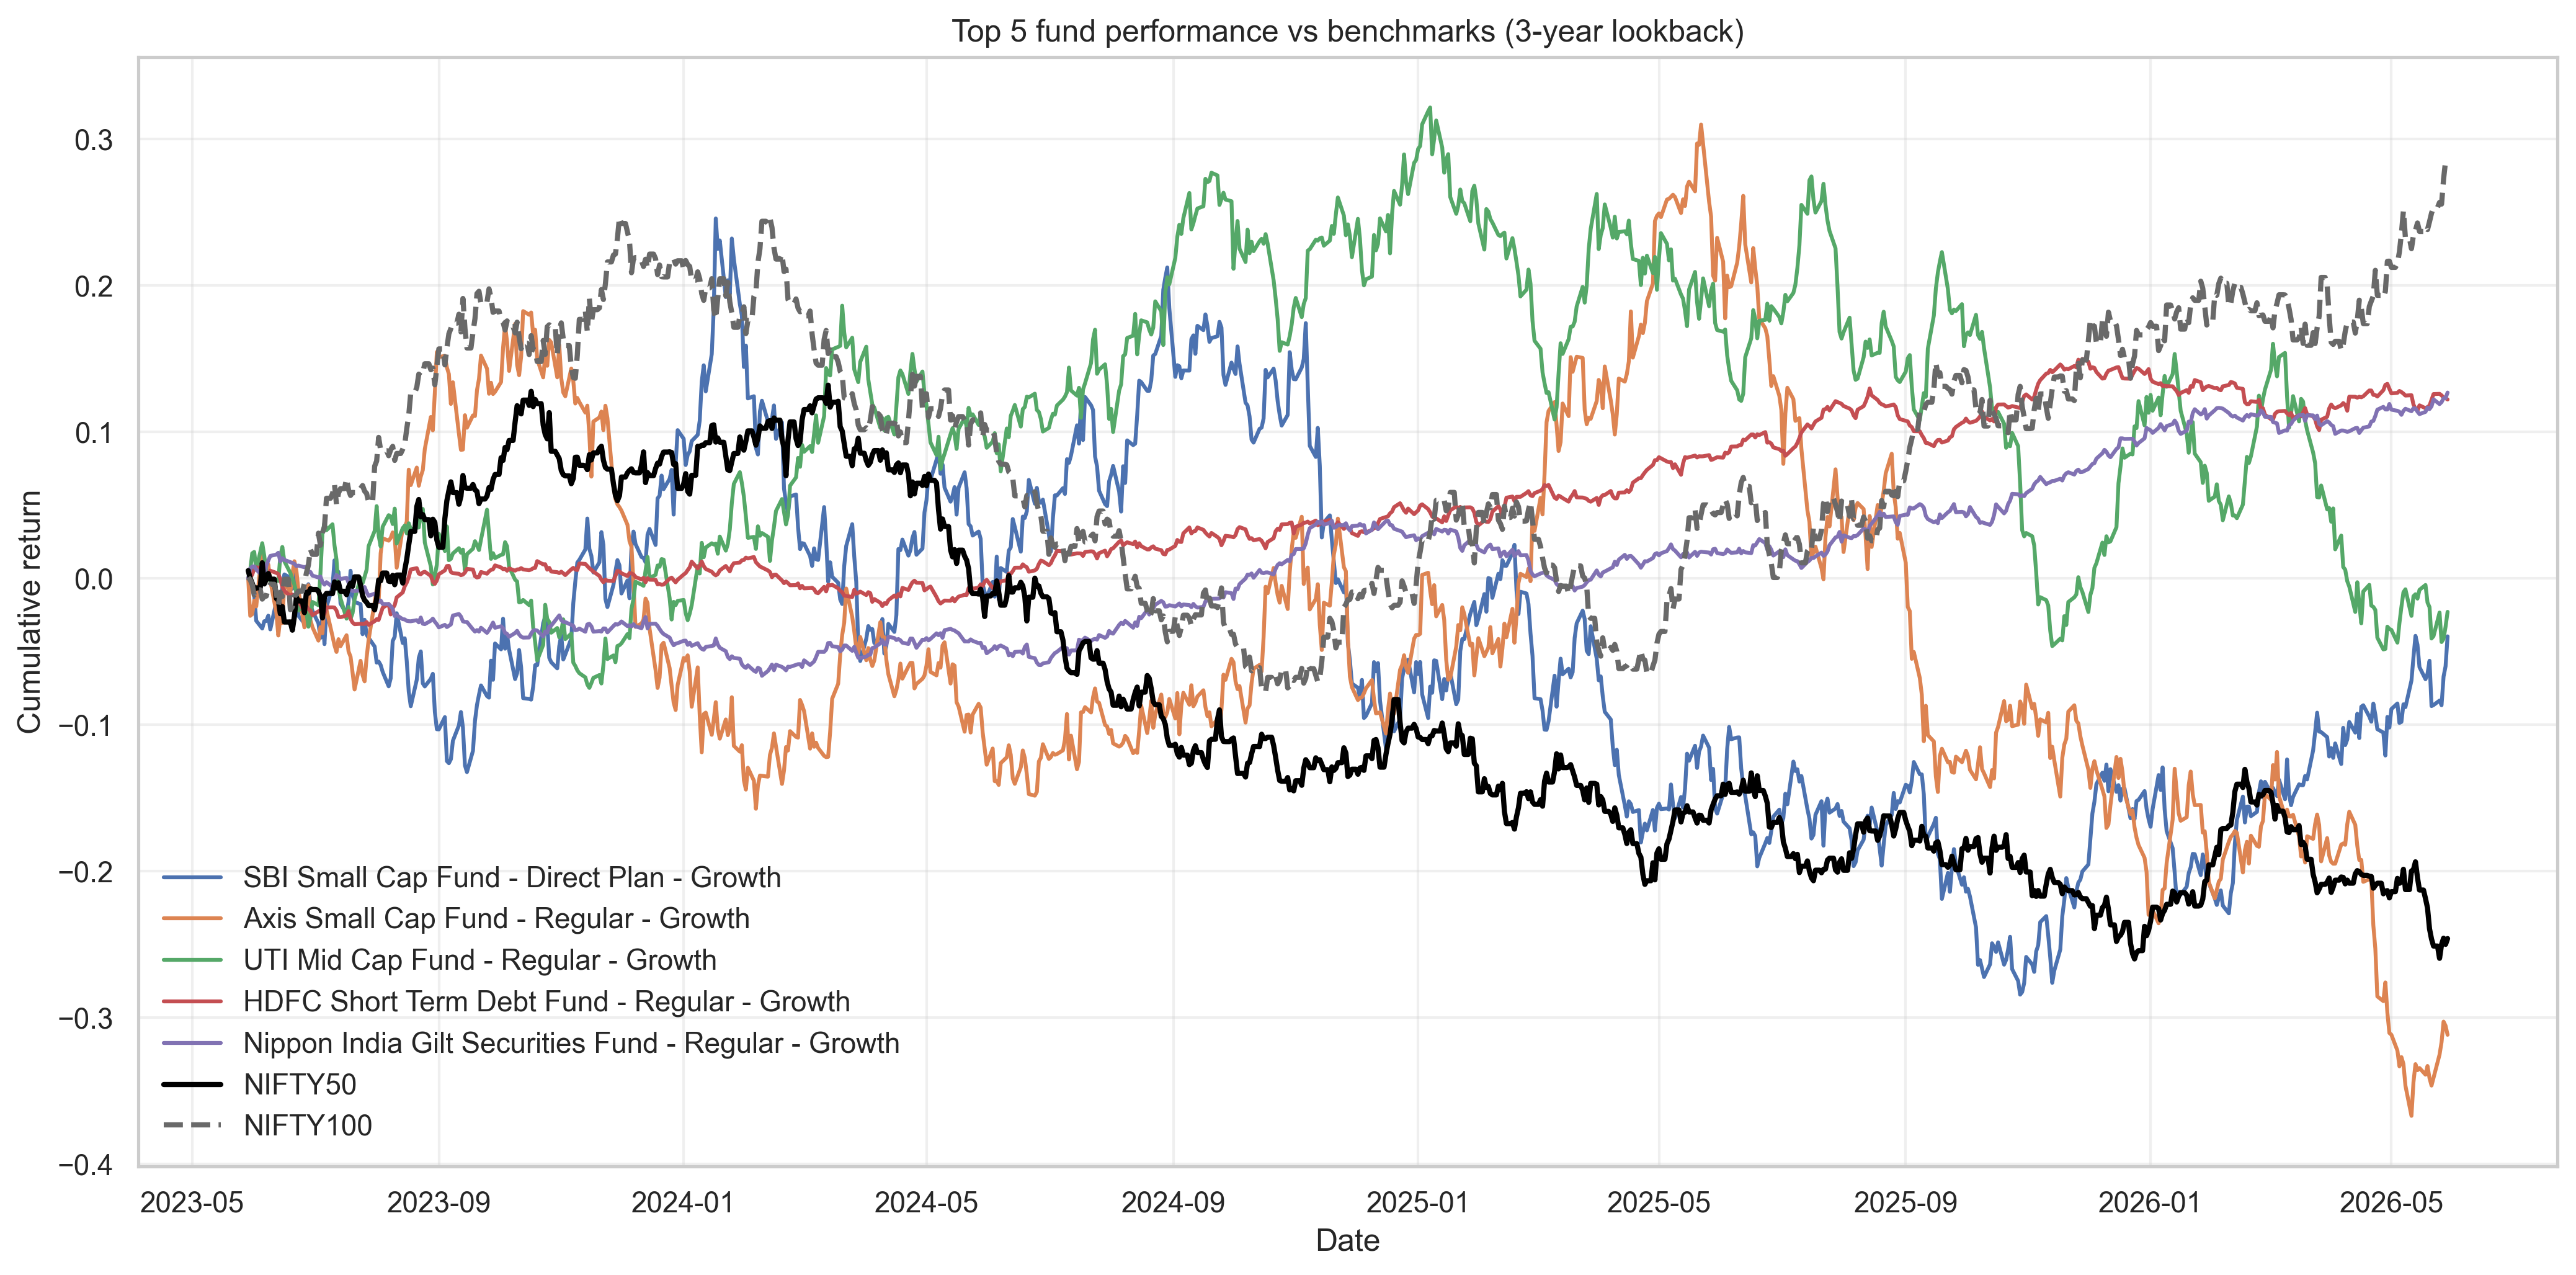

Saved benchmark comparison chart to C:\Users\JAY MISTRY\OneDrive\Desktop\Bluestock_mf_capstone\reports\benchmark_comparison.png


In [20]:
# 8) Benchmark comparison chart (top 5 funds vs benchmark over 3 years)
from IPython.display import Image, display

benchmark_indices = benchmark_indices.copy()
benchmark_indices['date'] = pd.to_datetime(benchmark_indices['date'])
benchmark_pivot = (
    benchmark_indices.pivot(index='date', columns='index_name', values='close_value')
    .sort_index()
    .resample('D').ffill()
)
benchmark_pivot = benchmark_pivot[['NIFTY50'] + [c for c in benchmark_pivot.columns if c != 'NIFTY50']]

if 'NIFTY100' not in benchmark_pivot.columns:
    benchmark_pivot['NIFTY100'] = benchmark_pivot['NIFTY50']

benchmark_pivot['NIFTY50_return'] = benchmark_pivot['NIFTY50'].pct_change().fillna(0)
benchmark_pivot['NIFTY100_return'] = benchmark_pivot['NIFTY100'].pct_change().fillna(0)
benchmark_pivot = benchmark_pivot.dropna()

latest_date = benchmark_pivot.index.max()
start_date = latest_date - pd.DateOffset(years=3)
benchmark_pivot = benchmark_pivot[benchmark_pivot.index >= start_date]

fig, ax = plt.subplots(figsize=(14, 7))
for code in scorecard['amfi_code'].head(5):
    fund_series = nav_returns[nav_returns['amfi_code'] == code].sort_values('date')
    fund_series = fund_series[['date', 'nav']].dropna()
    fund_series = fund_series[fund_series['date'] >= start_date]
    if fund_series.empty:
        continue
    fund_series['cum_return'] = (fund_series['nav'] / fund_series['nav'].iloc[0] - 1)
    ax.plot(fund_series['date'], fund_series['cum_return'], label=fund_lookup.get(code, f'Scheme {code}'))

ax.plot(benchmark_pivot.index, (1 + benchmark_pivot['NIFTY50_return']).cumprod() - 1, label='NIFTY50', linewidth=2, color='black')
ax.plot(benchmark_pivot.index, (1 + benchmark_pivot['NIFTY100_return']).cumprod() - 1, label='NIFTY100', linewidth=2, linestyle='--', color='dimgray')
ax.set_title('Top 5 fund performance vs benchmarks (3-year lookback)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative return')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
output_file = output_dir / 'benchmark_comparison.png'
fig.savefig(output_file, dpi=300, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(output_file)))
print('Saved benchmark comparison chart to', output_file)